In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from catboost import CatBoostRegressor
from sklearn.metrics import f1_score, roc_auc_score
from sentence_transformers import SentenceTransformer
import matplotlib.pyplot as plt
import pickle

import torch 
import random
from tqdm import tqdm

# Зафиксируем сиды, чтобы обучение было воспроизводимым.
seed = 1001
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(seed)

import warnings
warnings.filterwarnings("ignore")

# load data

In [2]:
df = pd.read_csv('interactions_train.csv')
df

,user_id,item_id,last_watch_dt,total_dur,watched_pct
0,3,10139,2021-04-25,103.0,2.0
1,3,7204,2021-07-17,28.0,1.0
2,3,12928,2021-08-17,845.0,15.0
3,3,3897,2021-08-17,901.0,15.0
4,4,811,2021-06-12,6191.0,100.0
...,...,...,...,...,...
922962,958981,14710,2021-08-16,7365.0,89.0
922963,958983,6288,2021-05-02,6734.0,100.0
922964,958983,3535,2021-05-03,7178.0,94.0
922965,958983,8556,2021-05-10,2690.0,51.0


In [3]:
user = pd.read_csv('users.csv')
user

,user_id,age,income,sex,kids_flg
0,523815,age_25_34,income_60_90,М,1
1,840727,age_18_24,income_20_40,М,0
2,558190,age_45_54,income_40_60,Ж,0
3,331576,age_45_54,income_20_40,Ж,0
4,749138,age_35_44,income_60_90,Ж,0
...,...,...,...,...,...
840192,159128,age_65_inf,income_0_20,Ж,0
840193,27937,age_18_24,income_20_40,Ж,1
840194,633813,NaN,NaN,NaN,0
840195,331859,NaN,NaN,Ж,0


In [4]:
item = pd.read_csv('items.csv')
item

,item_id,content_type,title,title_orig,release_year,genres,countries,for_kids,age_rating,studios,directors,actors,keywords
0,10964,film,Item_000000,TitleOrig_000000,2004.0,"Genre_000000, Genre_000001, Genre_000002, Genr...",Country_000000,NaN,16.0,NaN,Director_000000,"Actor_000000, Actor_000001, Actor_000002, Acto...","Keyword_000000, Keyword_000001, Keyword_000002..."
1,2294,film,Item_000001,TitleOrig_000001,2016.0,"Genre_000001, Genre_000004, Genre_000005",Country_000001,NaN,16.0,NaN,Director_000001,"Actor_000020, Actor_000021, Actor_000022, Acto...","Keyword_000024, Keyword_000025, Keyword_000026..."
2,1691,film,Item_000002,TitleOrig_000002,2013.0,"Genre_000006, Genre_000001, Genre_000007, Genr...",Country_000002,NaN,16.0,NaN,Director_000002,"Actor_000040, Actor_000041, Actor_000042, Acto...","Keyword_000035, Keyword_000036, Keyword_000037..."
3,352,film,Item_000003,TitleOrig_000003,2017.0,"Genre_000000, Genre_000001, Genre_000003",Country_000003,NaN,16.0,NaN,Director_000003,"Actor_000054, Actor_000055, Actor_000056, Acto...","Keyword_000057, Keyword_000058, Keyword_000059..."
4,8281,film,Item_000004,NaN,1980.0,"Genre_000000, Genre_000009, Genre_000010, Genr...",Country_000004,NaN,12.0,Studio_000000,Director_000004,"Actor_000074, Actor_000075, Actor_000076, Acto...","Keyword_000072, Keyword_000073, Keyword_000074..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
15958,13638,series,Item_015664,TitleOrig_010817,2020.0,"Genre_000000, Genre_000007, Genre_000006","Country_000050, Country_000007",NaN,16.0,NaN,Director_000585,"Actor_061870, Actor_061871, Actor_015894, Acto...","Keyword_000405, Keyword_006322, Keyword_012757..."
15959,10382,series,Item_001078,NaN,2022.0,"Genre_000000, Genre_000008",Country_000005,0.0,18.0,NaN,Director_001109,"Actor_003261, Actor_006717, Actor_007062, Acto...","Keyword_002708, Keyword_000280, Keyword_000088"
15960,1798,series,Item_015665,TitleOrig_010818,2019.0,"Genre_000000, Genre_000007, Genre_000006",Country_000005,0.0,18.0,NaN,"Director_008834, Director_008082, Director_008835","Actor_018960, Actor_014082, Actor_061876, Acto...","Keyword_043679, Keyword_000257, Keyword_000088"
15961,14241,series,Item_015666,TitleOrig_010819,2021.0,"Genre_000000, Genre_000009, Genre_000006",Country_000005,0.0,18.0,NaN,"Director_008836, Director_008743","Actor_061878, Actor_061879, Actor_061880, Acto...","Keyword_019329, Keyword_042747, Keyword_000246..."


# data analyze

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 922967 entries, 0 to 922966
Data columns (total 5 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   user_id        922967 non-null  int64  
 1   item_id        922967 non-null  int64  
 2   last_watch_dt  922967 non-null  object 
 3   total_dur      922966 non-null  float64
 4   watched_pct    922782 non-null  float64
dtypes: float64(2), int64(2), object(1)
memory usage: 35.2+ MB


In [6]:
df['last_watch_dt'] = pd.to_datetime(df['last_watch_dt'])
df['watch_day'] = df['last_watch_dt'].dt.day
df['watch_month'] = df['last_watch_dt'].dt.month
df['watch_year'] = df['last_watch_dt'].dt.year

In [7]:
df.drop(columns = ['last_watch_dt'], inplace = True)

In [8]:
df.dropna(inplace = True)

In [9]:
user.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 840197 entries, 0 to 840196
Data columns (total 5 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   user_id   840197 non-null  int64 
 1   age       826102 non-null  object
 2   income    825421 non-null  object
 3   sex       826366 non-null  object
 4   kids_flg  840197 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 32.1+ MB


In [10]:
user_cat_cols = ['age', 'income', 'sex']

In [11]:
for col in tqdm(user_cat_cols):
    user[col].fillna(' ', inplace=True)

100%|██████████| 3/3 [00:00<00:00, 67.44it/s]


In [12]:
user.drop(columns = ['income', 'kids_flg', 'sex', 'age'], inplace = True)

In [13]:
user = pd.get_dummies(user)

In [14]:
item.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15963 entries, 0 to 15962
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   item_id       15963 non-null  int64  
 1   content_type  15963 non-null  object 
 2   title         15963 non-null  object 
 3   title_orig    11218 non-null  object 
 4   release_year  15865 non-null  float64
 5   genres        15963 non-null  object 
 6   countries     15926 non-null  object 
 7   for_kids      566 non-null    float64
 8   age_rating    15961 non-null  float64
 9   studios       1065 non-null   object 
 10  directors     14454 non-null  object 
 11  actors        13344 non-null  object 
 12  keywords      15540 non-null  object 
dtypes: float64(3), int64(1), object(9)
memory usage: 1.6+ MB


In [15]:
item.drop(columns = ['for_kids', 'studios', 'title_orig'], inplace = True)

In [16]:
item_cat_cols = ['content_type', 'title', 'genres', 'countries', 'directors', 'actors', 'keywords']
for col in tqdm(item_cat_cols):
    item[col].fillna(' ', inplace=True)

100%|██████████| 7/7 [00:00<00:00, 1107.97it/s]


In [17]:
df = df.merge(user, on = 'user_id', how = 'left')

In [18]:
df = df.merge(item, on = 'item_id', how = 'left')

# eda & split

In [19]:
df.isna().sum()

user_id          0
item_id          0
total_dur        0
watched_pct      0
watch_day        0
watch_month      0
watch_year       0
content_type     0
title            0
release_year    66
genres           0
countries        0
age_rating       0
directors        0
actors           0
keywords         0
dtype: int64

In [20]:
from collections import Counter
Counter(df['release_year']).most_common(1)

[(2023.0, 190066)]

In [21]:
df['release_year'].fillna(2023, inplace = True)
df.isna().sum().sum()

0

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_numeric_distributions(df: pd.DataFrame, bins: int = 30, figsize=(12, 5)):
    """
    Строит распределения для всех числовых столбцов датафрейма.

    Параметры:
        df (pd.DataFrame): входной датафрейм
        bins (int): количество бинов для гистограмм
        figsize (tuple): размер одного графика
    """
    numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
    
    if len(numeric_cols) == 0:
        print("Нет числовых столбцов для отображения.")
        return

    for col in numeric_cols:
        fig, axes = plt.subplots(1, 2, figsize=figsize)
        fig.suptitle(f'Распределение признака: {col}', fontsize=14, fontweight='bold')

        # Гистограмма
        axes[0].hist(df[col].dropna(), bins=bins, color='skyblue', edgecolor='black')
        axes[0].set_title('Гистограмма')
        axes[0].set_xlabel(col)
        axes[0].set_ylabel('Частота')

        # Boxplot
        axes[1].boxplot(df[col].dropna(), vert=False, patch_artist=True,
                        boxprops=dict(facecolor='lightgreen'))
        axes[1].set_title('Boxplot')
        axes[1].set_xlabel(col)

        plt.tight_layout()
        plt.show()

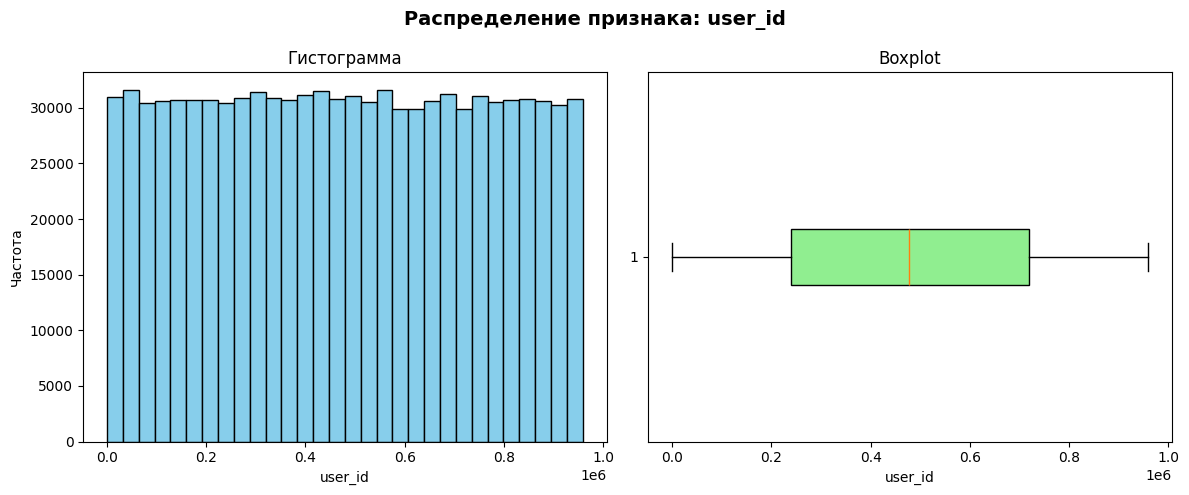

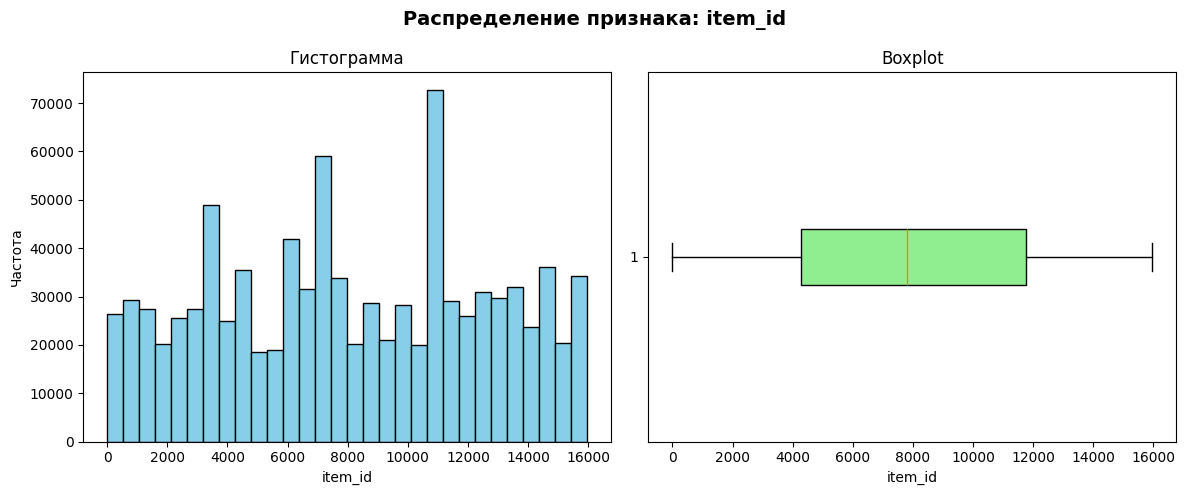

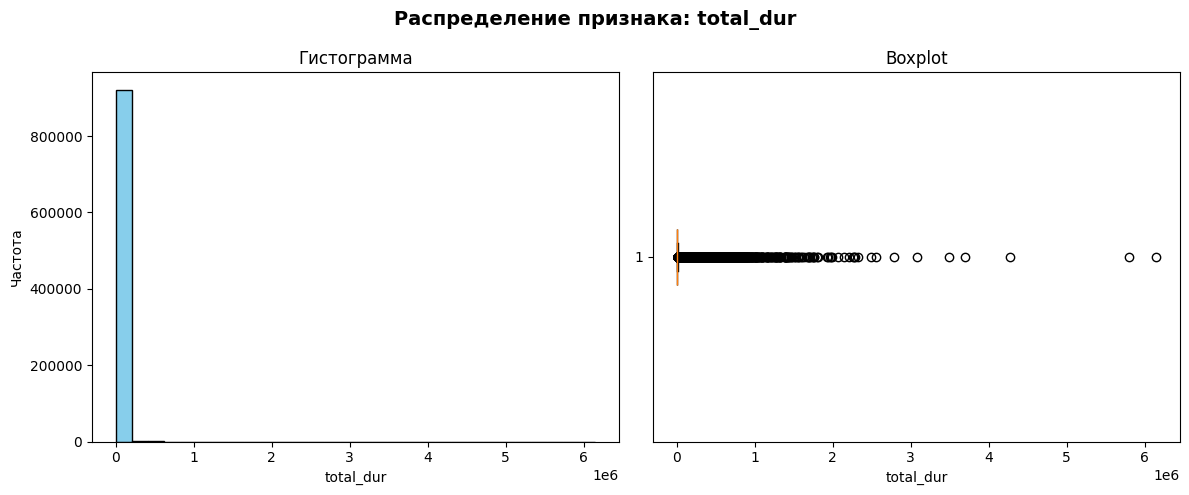

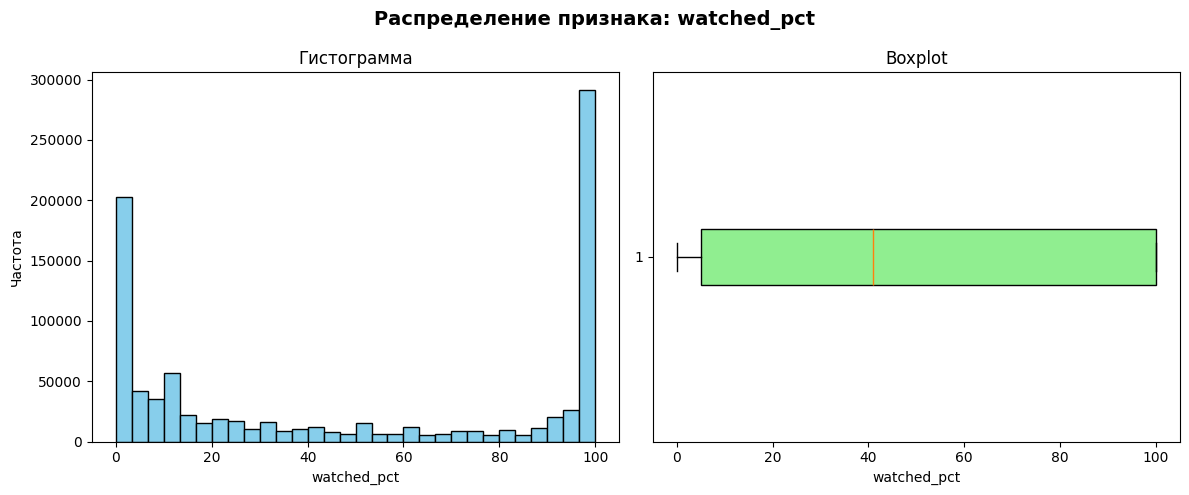

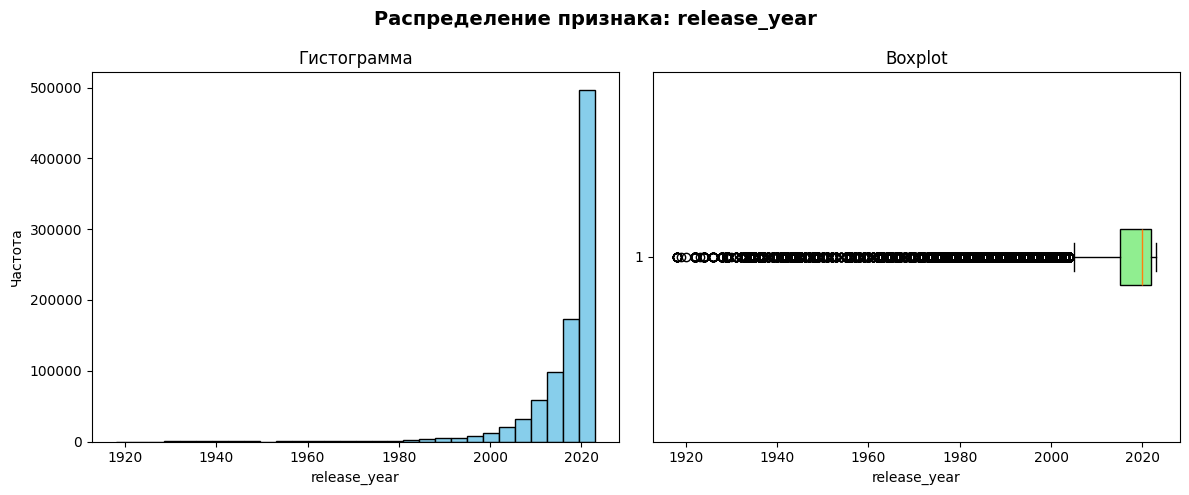

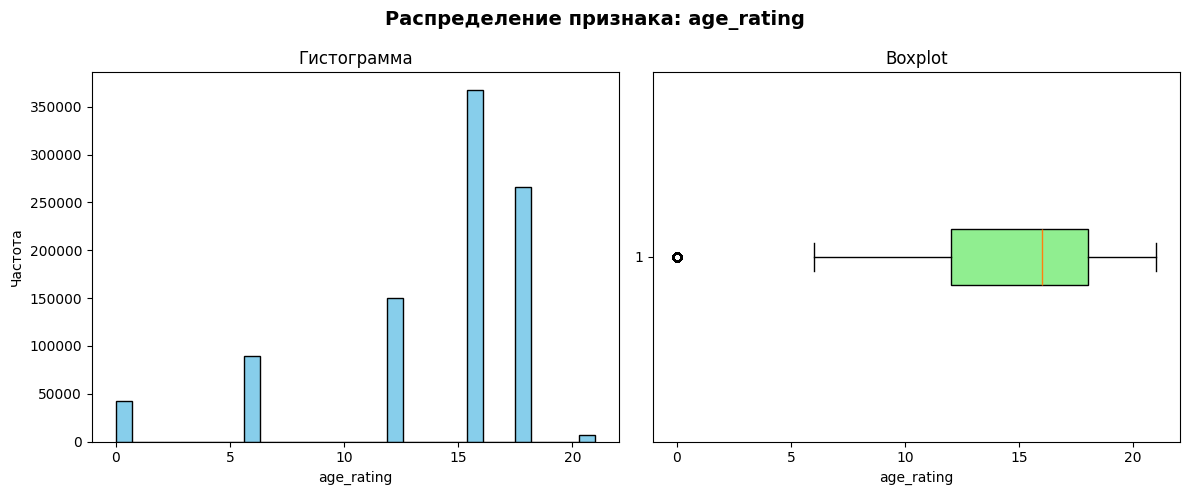

In [23]:
plot_numeric_distributions(df)

In [ ]:
# Load the model
model = SentenceTransformer("sparse-encoder-testing/splade-bert-tiny-nq")

dir_emb = []
for q in tqdm(df['directors']):
    dir_emb.append(model.encode(q))
np.save('dir_emb.npy', np.array(dir_emb))

act_emb = []
for q in tqdm(df['actors']):
    act_emb.append(model.encode(q))
np.save('act_emb.npy', np.array(act_emb))

key_emb = []
for q in tqdm(df['keywords']):
    key_emb.append(model.encode(q))
np.save('key_emb.npy', np.array(key_emb))

In [25]:
key_emb = np.load('key_emb.npy')
act_emb = np.load('act_emb.npy')
dir_emb = np.load('dir_emb.npy')

df['keywords'] = key_emb
df['actors'] = act_emb
df['directors'] = dir_emb

In [26]:
X = df.drop(columns = ['watched_pct', 'item_id', 'user_id'])
y = df['watched_pct']

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# model

In [28]:
model = CatBoostRegressor(iterations=1000000, od_wait = 3000, random_seed = 42, task_type='GPU')
model

In [30]:
model.fit(X_train, y_train, verbose = 1, 
          cat_features=['content_type', 'title', 'genres', 'countries'],
          eval_set=(X_test, y_test), use_best_model=True)

59864:	learn: 5.8206137	test: 6.3032625	best: 6.3031854 (59828)	total: 28m 7s	remaining: 7h 21m 44s
59865:	learn: 5.8206046	test: 6.3032763	best: 6.3031854 (59828)	total: 28m 7s	remaining: 7h 21m 44s
59866:	learn: 5.8205864	test: 6.3032823	best: 6.3031854 (59828)	total: 28m 7s	remaining: 7h 21m 45s
59867:	learn: 5.8205706	test: 6.3032960	best: 6.3031854 (59828)	total: 28m 7s	remaining: 7h 21m 45s
59868:	learn: 5.8205681	test: 6.3032947	best: 6.3031854 (59828)	total: 28m 7s	remaining: 7h 21m 45s
59869:	learn: 5.8205599	test: 6.3032937	best: 6.3031854 (59828)	total: 28m 7s	remaining: 7h 21m 45s
59870:	learn: 5.8205483	test: 6.3032776	best: 6.3031854 (59828)	total: 28m 8s	remaining: 7h 21m 45s
59871:	learn: 5.8205392	test: 6.3032735	best: 6.3031854 (59828)	total: 28m 8s	remaining: 7h 21m 46s
59872:	learn: 5.8205362	test: 6.3032741	best: 6.3031854 (59828)	total: 28m 8s	remaining: 7h 21m 46s
59873:	learn: 5.8205243	test: 6.3032700	best: 6.3031854 (59828)	total: 28m 8s	remaining: 7h 21m 46s


In [31]:
print(f1_score((model.predict(X_test) > 50).astype(int), (y_test > 50).astype(int), average='macro'))
roc_auc_score((model.predict(X_test) > 50).astype(int), (y_test > 50).astype(int))

0.981791085397848


0.9813584431471557

In [46]:
# save the model
filename = 'cat_model.sav'
pickle.dump(model, open(filename, 'wb'))

Text(0.5, 1.0, 'Feature Importance')

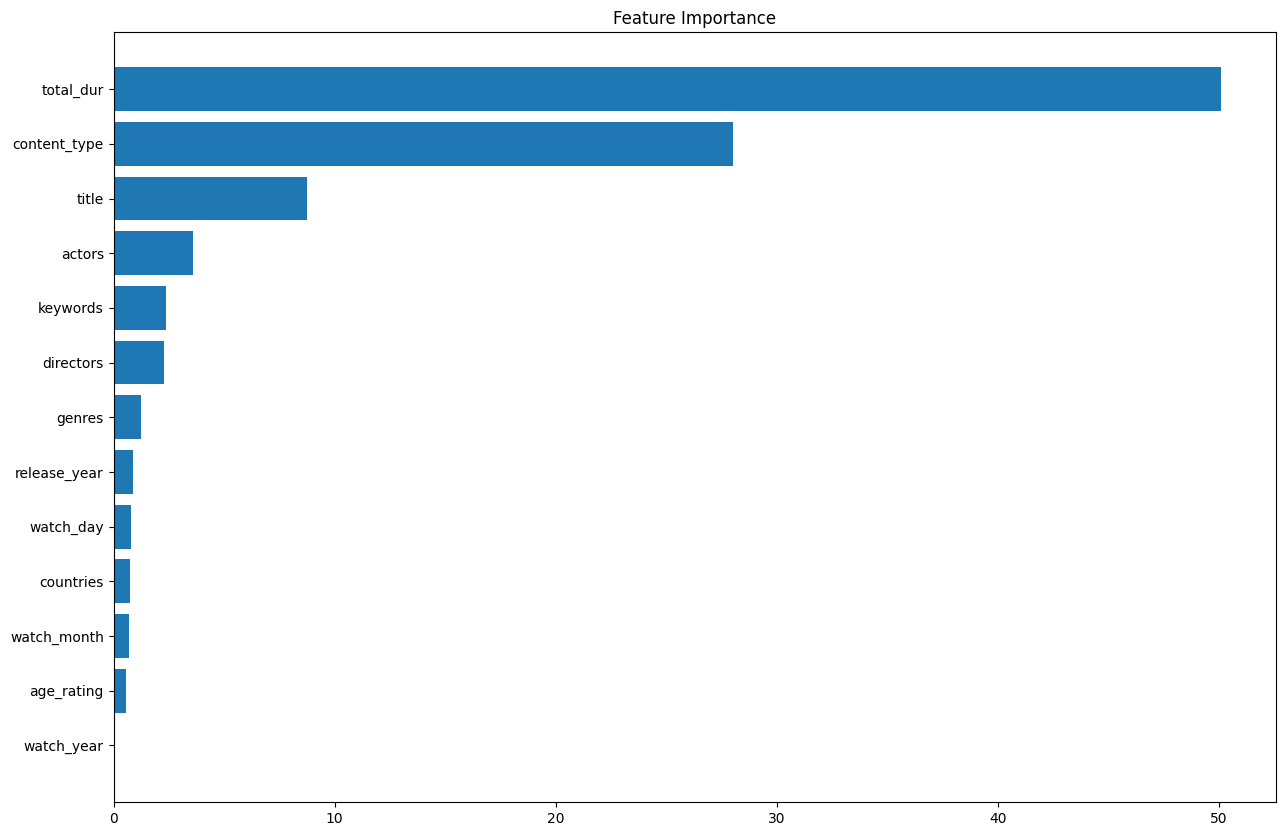

In [32]:
feature_importance = model.feature_importances_
sorted_idx = np.argsort(feature_importance)
fig = plt.figure(figsize=(15, 10))
plt.barh(range(len(sorted_idx)), feature_importance[sorted_idx], align='center')
plt.yticks(range(len(sorted_idx)), np.array(X_test.columns)[sorted_idx])
plt.title('Feature Importance')